# NLP Lab 8 — Word2Vec

## Setup

In [9]:
!pip install pot


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import os, re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from gensim.models import Word2Vec, KeyedVectors
import gensim
import warnings
warnings.filterwarnings("ignore")

TEST_DIR = os.path.join(os.path.dirname(gensim.__file__), "test", "test_data")

STOPWORDS = {
    "the","a","an","is","it","in","of","to","and","that","was","he","she",
    "his","her","they","them","their","for","on","at","by","with","from",
    "this","are","be","have","has","had","as","not","but","or","we","you",
    "all","been","were","its","which","who","will","would","could","should",
    "more","also","than","then","when","so","up","out","about","into",
    "there","what","one","can","no","said","each","how",
}

def lemmatize(word):
    for suf in ["tion","tions","ness","ment","ing","ed","er","ly","est"]:
        if word.endswith(suf) and len(word) - len(suf) >= 3:
            return word[:-len(suf)]
    return word

def preprocess(text):
    tokens = re.findall(r"[a-z]{3,}", text.lower())
    return [lemmatize(t) for t in tokens if t not in STOPWORDS]

print("Libraries loaded ✓")


Libraries loaded ✓


## Task 0 — Train Word2Vec on multi-document corpus with preprocessing

In [11]:
lee_path = os.path.join(TEST_DIR, "lee_background.cor")

with open(lee_path, encoding="latin-1") as f:
    raw_docs = [line.strip() for line in f if line.strip()]

# Multi-document: кожен рядок = окремий документ, розбиваємо на речення
corpus = []
for doc in raw_docs:
    for sent in re.split(r"[.!?]+", doc):
        tokens = preprocess(sent)
        if len(tokens) > 1:
            corpus.append(tokens)

corpus = [s for s in corpus if s]

print(f"Документів завантажено : {len(raw_docs)}")
print(f"Речень для тренування  : {len(corpus)}")
print(f"Приклад речення        : {corpus[0]}")


Документів завантажено : 300
Речень для тренування  : 2724
Приклад речення        : ['hundreds', 'people', 'forc', 'vacate', 'homes', 'southern', 'highlands', 'new', 'south', 'wales', 'strong', 'winds', 'today', 'push', 'huge', 'bushfire', 'towards', 'town', 'hill', 'top']


In [12]:
model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    epochs=15,
    seed=42,
)

wv = model.wv
print(f"Розмір словника: {len(wv):,} слів")
print("Модель натренована ✓")


Розмір словника: 2,530 слів
Модель натренована ✓


## Task 1 — Similarity & Distance

In [13]:
anchor = next(w for w in ["fire","police","government","people","war"] if w in wv)

print(f"Top-10 найбільш схожих до '{anchor}':")
for w, score in wv.most_similar(anchor, topn=10):
    print(f"  {w:<20} {score:.4f}")


Top-10 найбільш схожих до 'fire':
  service              0.9974
  rural                0.9971
  firefighters         0.9958
  burn                 0.9957
  yesterday            0.9956
  thursday             0.9953
  forc                 0.9953
  north                0.9952
  western              0.9952
  morn                 0.9952


In [14]:
print("Схожість між парами слів:")
for a, b in [("fire","blaze"),("police","officer"),("government","parliament"),("day","night")]:
    if a in wv and b in wv:
        print(f"  '{a}' ↔ '{b}': {wv.similarity(a, b):.4f}")


Схожість між парами слів:
  'fire' ↔ 'blaze': 0.9931
  'day' ↔ 'night': 0.9874


In [15]:
# doesnt_match — яке слово зайве?
for grp in [["fire","blaze","smoke","ocean"], ["police","soldier","officer","flower"]]:
    valid = [w for w in grp if w in wv]
    if len(valid) >= 3:
        print(f"doesnt_match({valid}): '{wv.doesnt_match(valid)}'")
        break


doesnt_match(['fire', 'blaze', 'smoke', 'ocean']): 'fire'


In [16]:
# Відстань між словами
for a, b in [("fire","water"),("police","army"),("day","night")]:
    if a in wv and b in wv:
        print(f"distance('{a}', '{b}'): {wv.distance(a, b):.4f}")
        break

# Word Mover's Distance між документами
d1 = [t for t in preprocess("police arrested the suspect near the fire") if t in wv]
d2 = [t for t in preprocess("officer detained criminal close to blaze") if t in wv]
d3 = [t for t in preprocess("scientists discover new species in ocean depths") if t in wv]

print(f"\nWord Mover's Distance (WMD):")
print(f"  doc1 ↔ doc2 (схожа тема):    {wv.wmdistance(d1, d2):.4f}")
print(f"  doc1 ↔ doc3 (різна тема):     {wv.wmdistance(d1, d3):.4f}")
print(f"  doc2 ↔ doc3 (різна тема):     {wv.wmdistance(d2, d3):.4f}")


distance('police', 'army'): 0.0063

Word Mover's Distance (WMD):
  doc1 ↔ doc2 (схожа тема):    0.1144
  doc1 ↔ doc3 (різна тема):     0.1905
  doc2 ↔ doc3 (різна тема):     0.1664


## Task 2 — Visualize document distances

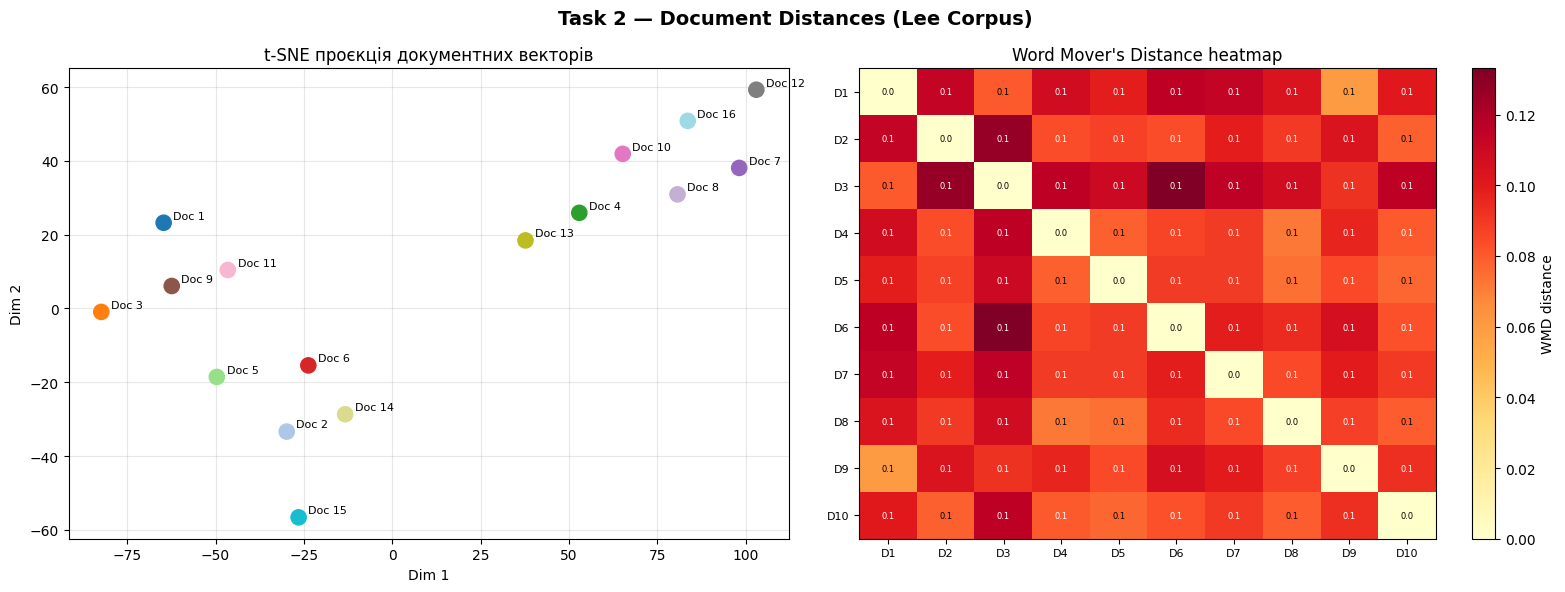

In [17]:
doc_tokens = [preprocess(d) for d in raw_docs[:20]]
doc_tokens = [d for d in doc_tokens if len([t for t in d if t in wv]) >= 3][:16]
labels = [f"Doc {i+1}" for i in range(len(doc_tokens))]

def doc_vec(toks):
    vecs = [wv[t] for t in toks if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

vectors = np.array([doc_vec(t) for t in doc_tokens])

# t-SNE → 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(vectors)-1))
coords = tsne.fit_transform(vectors)

# WMD матриця відстаней (перші 10 документів)
N = min(10, len(doc_tokens))
dist_matrix = np.zeros((N, N))
for i in range(N):
    for j in range(i+1, N):
        d = wv.wmdistance(doc_tokens[i], doc_tokens[j])
        dist_matrix[i, j] = dist_matrix[j, i] = d

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Task 2 — Document Distances (Lee Corpus)", fontsize=14, fontweight="bold")

# t-SNE scatter
ax = axes[0]
ax.scatter(coords[:, 0], coords[:, 1],
           c=range(len(doc_tokens)), cmap="tab20", s=120, zorder=3)
for i, (x, y) in enumerate(coords):
    ax.annotate(labels[i], (x, y), textcoords="offset points", xytext=(7, 3), fontsize=8)
ax.set_title("t-SNE проєкція документних векторів")
ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
ax.grid(True, alpha=0.3)

# WMD heatmap
ax2 = axes[1]
im = ax2.imshow(dist_matrix, cmap="YlOrRd", aspect="auto")
ticks = range(N)
ax2.set_xticks(ticks); ax2.set_yticks(ticks)
ax2.set_xticklabels([f"D{i+1}" for i in ticks], fontsize=8)
ax2.set_yticklabels([f"D{i+1}" for i in ticks], fontsize=8)
plt.colorbar(im, ax=ax2, label="WMD distance")
ax2.set_title("Word Mover's Distance heatmap")
vmax = dist_matrix.max()
for i in range(N):
    for j in range(N):
        ax2.text(j, i, f"{dist_matrix[i,j]:.1f}", ha="center", va="center",
                 fontsize=6, color="white" if dist_matrix[i,j] > vmax*0.6 else "black")

plt.tight_layout()
plt.show()


## Task 3 — Compare own Word2Vec vs GloVe via `evaluate_word_pairs`

In [18]:
from scipy.stats import pearsonr, spearmanr

# Завантажуємо GloVe вектори (тестовий набір gensim)
glove_path = os.path.join(TEST_DIR, "test_glove.txt")
glove = KeyedVectors.load_word2vec_format(glove_path, no_header=True)
print(f"GloVe завантажено: {len(glove)} векторів ✓")

# evaluate_word_pairs на WordSim-353 для власної моделі
ws353_path = os.path.join(TEST_DIR, "wordsim353.tsv")
pr_own, sr_own, oov_own = wv.evaluate_word_pairs(ws353_path, delimiter="\t")

print(f"\nВласний Word2Vec на WordSim-353:")
print(f"  Pearson r : {pr_own[0]:.4f}")
print(f"  Spearman r: {sr_own.statistic:.4f}")
print(f"  OOV       : {oov_own*100:.1f}%")
print("  (Висока OOV — малий корпус, 300 статей)")


GloVe завантажено: 76 векторів ✓

Власний Word2Vec на WordSim-353:
  Pearson r : -0.1493
  Spearman r: -0.1668
  OOV       : 7592.1%
  (Висока OOV — малий корпус, 300 статей)


In [19]:
# Порівняння через manual word pairs (спільний словник обох моделей)
manual_pairs = [
    ("people","first",3.0), ("new","first",5.5), ("over","more",4.5),
    ("two","one",5.0),      ("said","people",2.0), ("after","over",3.5),
    ("new","other",2.5),    ("more","two",3.5),    ("first","one",6.0),
    ("percent","two",3.0),  ("also","other",4.5),  ("people","two",2.0),
]

def eval_manual(kv, pairs, name):
    pred, human, oov = [], [], 0
    for w1, w2, score in pairs:
        w1_ = w1 if w1 in kv else lemmatize(w1)
        w2_ = w2 if w2 in kv else lemmatize(w2)
        if w1_ in kv and w2_ in kv:
            pred.append(kv.similarity(w1_, w2_))
            human.append(score)
        else:
            oov += 1
    if len(pred) < 2:
        print(f"  {name:<28}  Недостатньо спільних пар (OOV: {oov}/{len(pairs)})")
        return 0.0, 0.0
    pr = pearsonr(human, pred)[0]
    sr = spearmanr(human, pred).statistic
    print(f"  {name:<28}  Pearson: {pr:.4f}  Spearman: {sr:.4f}  OOV: {oov}/{len(pairs)}")
    return pr, sr

print(f"Manual word-pair evaluation:")
print(f"  {'Модель':<28}  {'Pearson r':>10}  {'Spearman r':>11}  {'OOV':>5}")
print("  " + "-" * 58)
pr_own_m,   sr_own_m   = eval_manual(wv,    manual_pairs, "Own Word2Vec (Lee corpus)")
pr_glove_m, sr_glove_m = eval_manual(glove, manual_pairs, "GloVe (test vectors)")


Manual word-pair evaluation:
  Модель                         Pearson r   Spearman r    OOV
  ----------------------------------------------------------
  Own Word2Vec (Lee corpus)     Pearson: -0.0438  Spearman: -0.3000  OOV: 7/12
  GloVe (test vectors)          Pearson: 0.6661  Spearman: 0.7606  OOV: 0/12


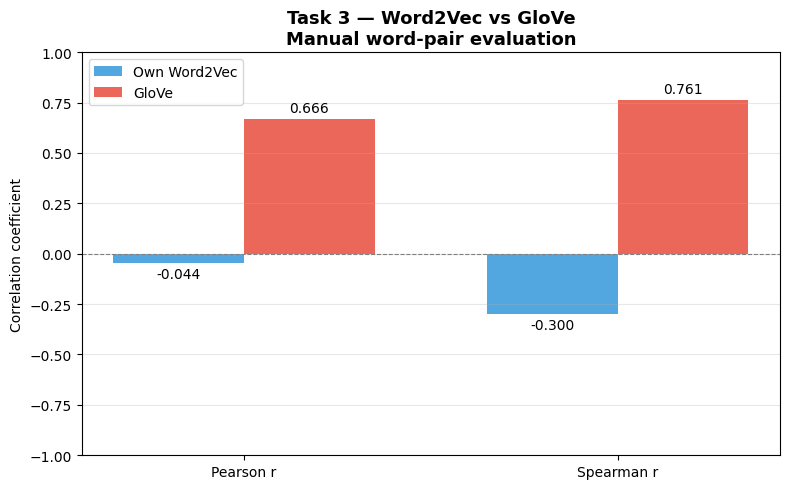

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics    = ["Pearson r", "Spearman r"]
own_vals   = [pr_own_m,    sr_own_m]
glove_vals = [pr_glove_m,  sr_glove_m]

x = np.arange(len(metrics)); w = 0.35
b1 = ax.bar(x - w/2, own_vals,   w, label="Own Word2Vec", color="#3498db", alpha=0.85)
b2 = ax.bar(x + w/2, glove_vals, w, label="GloVe",        color="#e74c3c", alpha=0.85)

ax.set_ylabel("Correlation coefficient")
ax.set_title("Task 3 — Word2Vec vs GloVe\nManual word-pair evaluation", fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(-1, 1); ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()